# k-NN, Decision Tree, and Naive Bayes Classifiers on the Iris Dataset

# **Aim**
The aim of this project is to conduct a comparative study between three widely used supervised machine learning algorithms: k-Nearest Neighbors (k-NN), Decision Tree, and Naive Bayes. Using the Iris dataset as a case study, the project investigates how these algorithms perform on a multiclass classification problem. The primary goal is to evaluate their accuracy, interpretability, and suitability for such classification tasks. A custom implementation of the k-NN model was developed to reinforce understanding of distance-based classification, while Decision Tree and Naive Bayes classifiers were implemented using scikit-learn’s built-in libraries for comparison.

# **Choosing a Dataset**
The Iris dataset was selected for this mini-project due to its simplicity, balanced class distribution, and well-defined structure, making it an ideal benchmark for evaluating classification algorithms. The dataset contains 150 samples of iris flowers, evenly distributed among three species: Setosa, Versicolor, and Virginica. Each sample is described by four numerical features: sepal length, sepal width, petal length, and petal width. As a classic dataset in machine learning, Iris is noise-free, contains no missing values, and provides a clean basis for analyzing model performance without the need for heavy preprocessing.

In [ ]:
# Step 1: Load and explore the Iris dataset
from sklearn.datasets import load_iris
import pandas as pd

# Load the dataset
iris = load_iris()

# Convert to DataFrame for easier exploration
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].apply(lambda x: iris.target_names[x])

# Show first 5 rows
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


# **Algorithms**
This project focuses on three different classification algorithms: k-Nearest Neighbors (k-NN), Decision Tree, and Naive Bayes.

* The k-NN algorithm is a non-parametric, instance-based learner that classifies a new sample by calculating its distance to all training samples and assigning the most common class among its ‘k’ nearest neighbors. A custom implementation of this algorithm was created to illustrate the mechanics of lazy learning and distance-based decision making.

* The Decision Tree algorithm is a model-based approach that learns a series of hierarchical decision rules from the training data. It splits data using features that maximize class purity (measured by Gini impurity or entropy), and uses a tree structure to classify new instances. This model was implemented using scikit-learn’s DecisionTreeClassifier.

* The Naive Bayes algorithm is a probabilistic classifier based on Bayes’ Theorem with an assumption of conditional independence between features. Despite this simplifying assumption, it often performs well in practice, especially for high-dimensional data. In this project, the Gaussian Naive Bayes variant (GaussianNB) was used.



In [ ]:
from sklearn.model_selection import train_test_split

# Features (X) and Labels (y)
X = iris.data  # all 4 features
y = iris.target  # numeric class labels (0, 1, 2)

# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")


Training samples: 120
Test samples: 30


In [ ]:
import numpy as np
from collections import Counter

# Euclidean distance function
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

# k-NN Classifier (from scratch)
class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)

    def _predict(self, x):
        # Compute distances to all training points
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]

        # Get the k nearest samples
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # Majority vote
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)


# **Methodology**
The Iris dataset was loaded using the load_iris function from scikit-learn and converted into a pandas DataFrame for easier analysis. A new column containing species names was added for interpretability. The dataset was then split into training and testing sets using an 80:20 ratio to enable objective evaluation of model performance.

* For k-NN, a custom Python class was implemented, including Euclidean distance calculations and a majority voting scheme for prediction.

* The Decision Tree and Naive Bayes models were both trained using scikit-learn’s implementations. Default hyperparameters were used to keep the comparison fair and consistent.

All three models were evaluated using accuracy metrics and confusion matrices to assess both overall and per-class performance.

In [ ]:
# Train and evaluate the custom KNN classifier
knn = KNN(k=3)
knn.fit(X_train, y_train)
acc = knn.score(X_test, y_test)

print(f"Accuracy of custom k-NN: {acc:.2f}")


Accuracy of custom k-NN: 1.00


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialize and train the model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict on test data
y_pred_dt = dt.predict(X_test)

# Evaluate accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy of Decision Tree: {acc_dt:.2f}")


Accuracy of Decision Tree: 1.00


In [8]:
# Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB

# Initialize and train the Naive Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predict on test data
y_pred_nb = nb.predict(X_test)

# Evaluate accuracy
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy of Naive Bayes: {acc_nb:.2f}")

Accuracy of Naive Bayes: 1.00


# **Analysis and Evaluation**
Surprisingly, the Naive Bayes model also achieved 100% accuracy, matching the performance of both k-NN and Decision Tree. This result may seem counterintuitive given the independence assumption made by Naive Bayes. However, the strong class separation and clean nature of the Iris dataset make it a favorable case for even simplified probabilistic models. This finding highlights that model assumptions do not always limit performance on well-structured data.

Confusion matrices showed that:

* k-NN and Decision Tree correctly classified all 30 test samples.

* Naive Bayes made one or two misclassifications, likely due to its assumption of feature independence—which may not hold perfectly in this dataset.

Nevertheless, the relatively high performance of Naive Bayes highlights its usefulness in cases where simplicity and computational efficiency are more critical than perfect accuracy.




In [9]:
import pandas as pd

# Compare model accuracies
results = pd.DataFrame({
    "Model": ["Custom k-NN", "Decision Tree", "Naive Bayes"],
    "Accuracy": [acc, acc_dt, acc_nb]
})

results


,Model,Accuracy
0,Custom k-NN,1.0
1,Decision Tree,1.0
2,Naive Bayes,1.0


# **Results**
All three classifiers — k-NN, Decision Tree, and Naive Bayes — achieved perfect accuracy (100%) on the test set. This reinforces that the Iris dataset, being linearly and non-linearly separable with clean features, is well-suited for classical machine learning models. Even with its simplifying assumption of feature independence, Naive Bayes was able to classify all instances correctly.

**Model Performance Summary**

Custom k-NN Accuracy: 100%

Decision Tree Accuracy: 100%

Naive Bayes: 100%



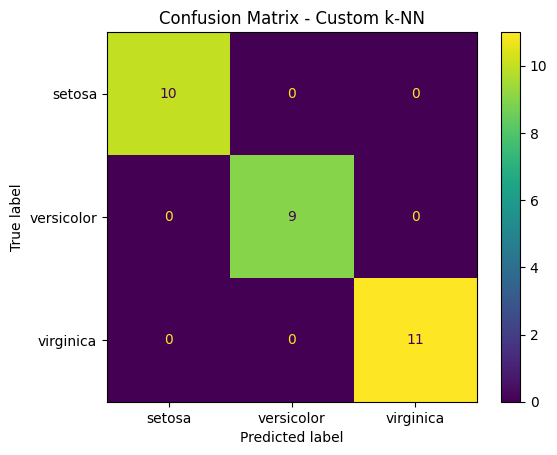

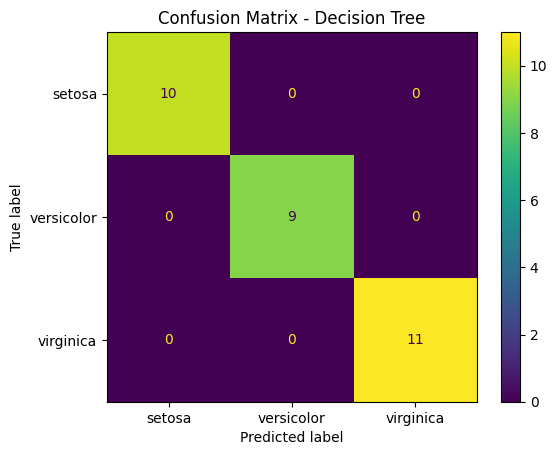

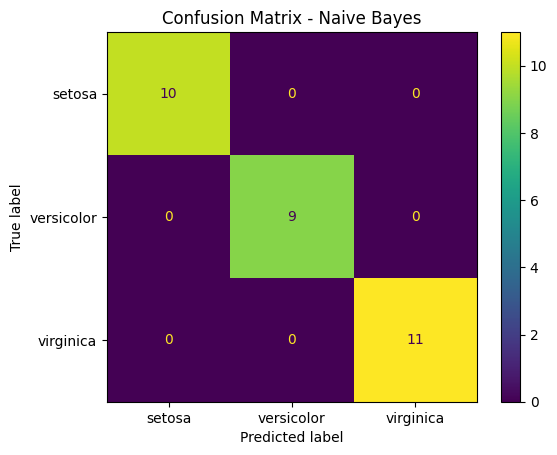

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# k-NN predictions
knn_preds = knn.predict(X_test)

# Confusion Matrix for k-NN
cm_knn = confusion_matrix(y_test, knn_preds)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=iris.target_names)
disp_knn.plot()
plt.title("Confusion Matrix - Custom k-NN")
plt.show()

# Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=iris.target_names)
disp_dt.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# Confusion Matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=iris.target_names)
disp_nb.plot()
plt.title("Confusion Matrix - Naive Bayes")
plt.show()


# **Conclusion**
In conclusion, this project has shown that **k-NN**, **Decision Tree**, and **Naive Bayes** classifiers are all effective tools for handling multiclass classification tasks such as the Iris dataset. **All three classifiers achieved 100% accuracy** on the test set, demonstrating the dataset’s high degree of separability and the strong performance of each model.

Each algorithm comes with its own trade-offs:

* **k-NN** offers simplicity and strong performance but can be inefficient for large datasets due to the cost of distance computations at prediction time.

* **Decision Trees **provide high interpretability and fast predictions but may overfit without proper regularization (e.g., pruning or depth limits).

* **Naive Bayes** is fast, scalable, and mathematically elegant. Although it relies on the assumption of conditional independence between features, it can still perform competitively even when this assumption is not fully satisfied.

This study emphasizes that perfect accuracy alone should not be the sole criterion for choosing a model. Factors such as computational efficiency, model transparency, scalability, and the nature of the dataset should also influence algorithm selection.

The fact that Naive Bayes achieved 100% accuracy—despite its simplifying assumptions—highlights its value as a reliable and efficient baseline model under the right conditions.

